In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Entendimento do negócio

Nessa primeira etapa, queremos exercitar o seu pensamento

1.   Item da lista
2.   Item da lista

analítico, não código. Nos traga a resposta para as seguintes perguntas de negócio:

Qual problema de negócio está sendo resolvido?

R = empresa cresceu, demanda cresceu, e houve problemas no nps, mas talvez não seja somente questões operacionais e sim com o segmento de clientes.
Por que o NPS é importante para um e-commerce?

R = variavel de saída que resume a experiencia do cliente e define sua relação com a marca, [marketing] sendo um divulgador positivo da marca (promotor) ou um possível churn ou divulgador negativo (detrator). [interna operacional] quais serviços ou departamentos estão com problemas. [e-commerce] reflexo no market share.
Quais áreas poderiam se beneficiar desses insights? Exemplos: logística, atendimento, pricing, produto etc.

R = suporte e atendimento ao cliente, logística (melhoria de entrega, tempo de entrega, etc), princing/descontos em preços de produtos, marketing na segmentação de clientes e criação de campanhas específicas e mais acertivas.
Além do entendimento do negócio, inclua uma reflexão (não precisa de dados externos obrigatórios):

Como o NPS impacta:
Recompra; - altos nps => melhor experiencia => mais compras do mesmo cliente
Boca a boca; - promotor (fala bem da empresa, mais indicações orgânicas) vs. detrator (fala mal da empresa, indica compra em concorrentes)
Market share em e-commerce. - efeito multiplicador de boas experiencias (nps) maior parcela do market share.
Quais indicadores de mercado poderiam complementar essa análise? Exemplos: benchmarks de NPS, SLA logístico, concorrência. Pesquisar mais, quais outras métricas utilizadas pelos e-commerces.

# 2. Definição da Target

### Qual é o alvo desse problema de negócio? Nessa segunda etapa queremos uma avaliação de entendimento conceitual, não técnico.

- Qual variável representa a satisfação do cliente?
  - R = nps
- Por que ela foi escolhida?
  - R = é a pontuação definida pelo próprio cliente ao final de uma experiência
- Em que momento da jornada essa informação é coletada?
  - R = final da exepriência
- Existe algum risco de usar essa variável de forma inadequada?
  - R = que é um problema pontual e não encontra a real causa de um problema, correlacionar a um setor específico por exemplo atendimento.

# 3. Análise Exploratória dos Dados (EDA)

Realize uma análise exploratória com foco em negócio, não só estatística. Responda:
- Quais fatores parecem mais críticos para a satisfação?
- O que mais gera detratores?
- Existe algum “ponto de ruptura” na experiência do cliente?
- Que tipo de cliente tende a ter NPS mais alto ou mais baixo?
Imagine que você está explicando isso para um(a) gerente de operações
que não entende estatística.

## Verificação das características e integridade do dataset

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/AnaRaquelCafe/POSTECH_AI_SCIENTIST/5274d2dac848ed75f15c49fc1885352bc5dcfd46/Base%20de%20dados%20Tech%20Challenge/desafio_nps_fase_1.csv')
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

A visualização primária das características do dataset nos apresenta 19 variáveis expressas em 2500 casos. Dessas variáveis, temos a seguinte classificação:
- qualitativas nominais:
  - custom_id, order_id,customer_region, repeat_purchase_30d
- quantitativas discretas
  - customer_age, customer_tenure_months, items_quantity, payment_installments, delivery_time_days, delivery_delay_days, delivery_attempts, customer_service_contacts, resolution_time_days, complaints_count,
- quantitativas contínuas
  - order_value, discount_value, freight_value, nps_score, csat_internal_score  

Essa abordagem irá facilitar nossa análise posterior, visto que cada tipo de variável suscita uma forma diferente de abordagem na análise exploratória

## Agrupamentos de dados


As variáveis analisadas podem ser agrupadas em subconjuntos que no futuro nos ajudarão na interpretação dos dados e no reconhecimento de padrões

**Dados do cliente**:
- customer_id (id do cliente)
- customer_age (idade do cliente)
- customer_region (região geográfica do cliente)
- customer_tenure_months (tempo de relacionamento do cliente com a empresa, em meses)

**Dados da encomenda**:
- order_id (id da encomenda)
- order_value (valor da encomenda)
- items_quantity (quantidade de itens)
- discount_value (valor do desconto)
- payment_installments (número de parcelas)

**Dados logísticos:**
- delivery_time_days (tempo de entrega em dias)
- delivery_delay_days (dias de atraso)
- freight_values (valor do frete)
- delivery_attempts (tentativas de entrega)

**Dados de atendimento:**
- customer_service_contacts (contatos do cliente com o atendimento)
- resolution_time_days (tempo de resolução em dias)
- complaints_count (número de reclamações)


**Dados de satisfação:**
- repeat_purchase_30d (recompra dentro de 30 dias)
- nps_score (satisfação do cliente NPS)
- csat_internal_score (Score interno de satisfação)


In [4]:
customer_variables = ['customer_id','customer_age','customer_region','customer_tenure_months']
order_variables = ['order_id','order_value','items_quantity','discount_value','payment_installments']
delivery_variables = ['delivery_time_days','delivery_delay_days','freight_value','delivery_attempts']
service_variables = ['customer_service_contacts','resolution_time_days','complaints_count']
satisfaction_variables = ['repeat_purchase_30d','nps_score','csat_internal_score']

## Análise de dados de uma variável

Nessa primeira etapa da análise propriamente dita, buscaremos padrões mais evidentes nos dados simples

### Dados do cliente

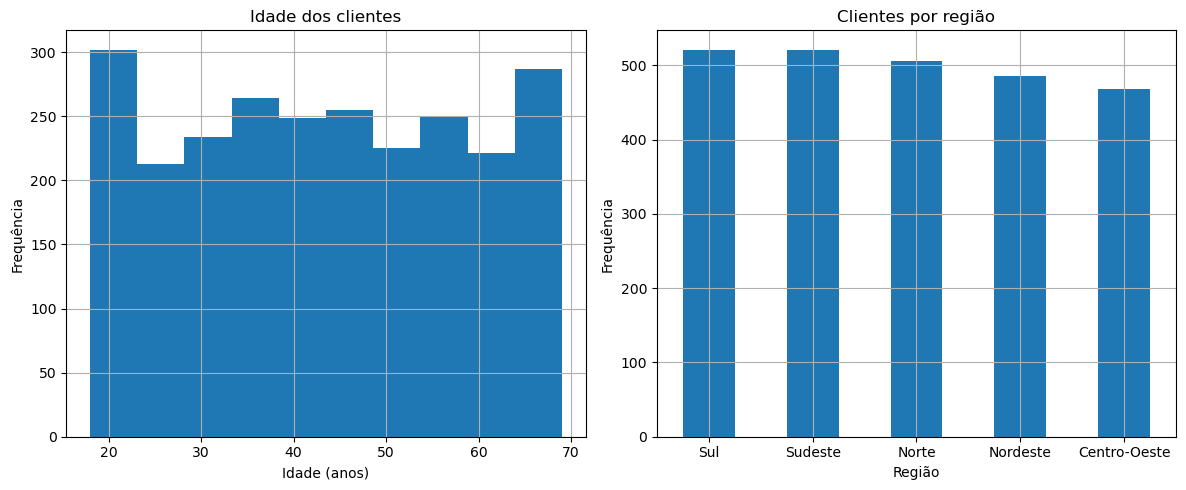

In [5]:
#Grades do plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1, contendo o histograma dos dados de idade dos cliente. Testamos alguns bins e o 10 nos pareceu mais apresentável
df['customer_age'].hist(bins=10, ax = axs[0])
axs[0].set_title('Idade dos clientes')
axs[0].set_xlabel('Idade (anos)')
axs[0].set_ylabel('Frequência')
axs[0].grid(True)

# Gráfico 2, contendo a frequência por região geográfica. Utilizamos o tick_params para manter os rótulos das barras na horizontal
region_counts = df['customer_region'].value_counts().plot(kind='bar')
axs[1].set_title('Clientes por região')
axs[1].set_xlabel('Região')
axs[1].set_ylabel('Frequência')
axs[1].grid(True)
axs[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Dados da encomenda

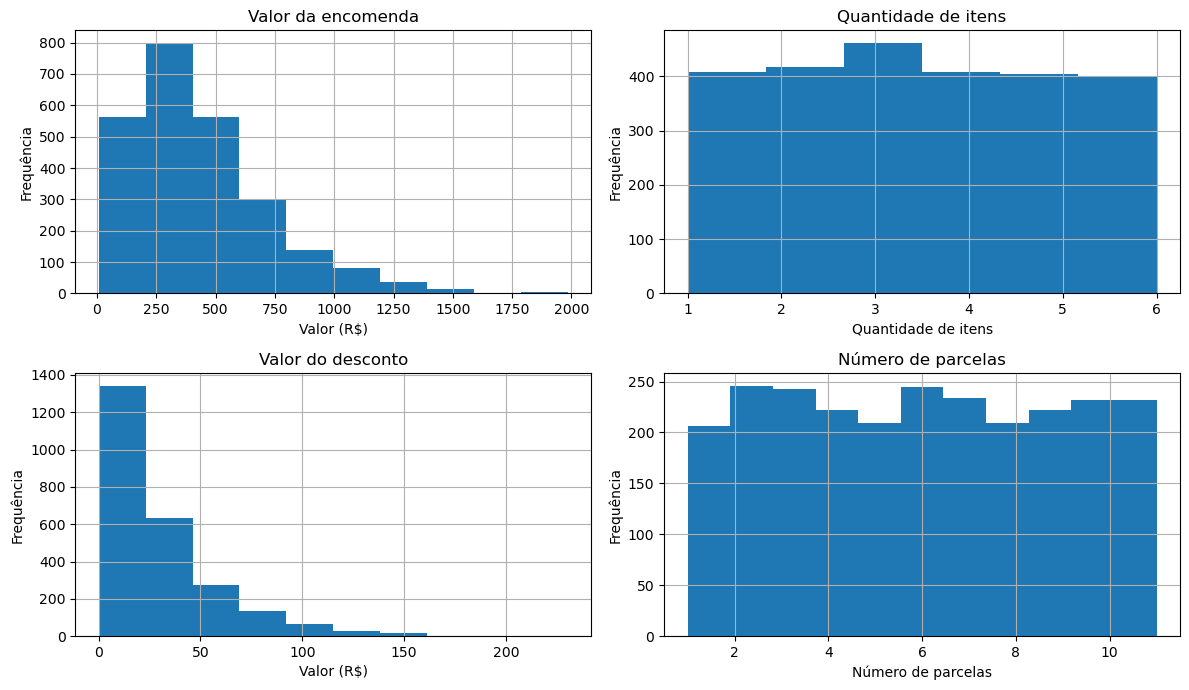

In [48]:
#Grades do plot em duas linhas e duas colunas
fig, axs = plt.subplots(2, 2, figsize=(12, 7))

# Gráfico 3, contendo o histograma dos dados de idade dos cliente. Testamos alguns bins e o 10 nos pareceu mais apresentável
df['order_value'].hist(bins=10, ax = axs[0,0])
axs[0,0].set_xlabel('Valor (R$)')
axs[0,0].set_ylabel('Frequência')
axs[0,0].set_title('Valor da encomenda')
axs[0,0].grid(True)


# Gráfico 4, contendo o histograma da quantidade de itens por compra
df['items_quantity'].hist(bins=6, ax = axs[0,1])
axs[0,1].set_xlabel('Quantidade de itens')
axs[0,1].set_ylabel('Frequência')
axs[0,1].set_title('Quantidade de itens')
axs[0,1].grid(True)

# Gráfico 5, contendo o histograma dos valores de desconto no valor do produto
df['discount_value'].hist(bins=10, ax = axs[1,0])
axs[1,0].set_xlabel('Valor (R$)')
axs[1,0].set_ylabel('Frequência')
axs[1,0].set_title('Valor do desconto')
axs[1,0].grid(True)

# Gráfico 6, contendo o histograma do número de vezes nas quais os pedidos foram parcelados
df['payment_installments'].hist(bins=11, ax = axs[1,1])
axs[1,1].set_xlabel('Número de parcelas')
axs[1,1].set_ylabel('Frequência')
axs[1,1].set_title('Número de parcelas')
axs[1,1].grid(True)


plt.tight_layout()
plt.show()

### Dados logísticos

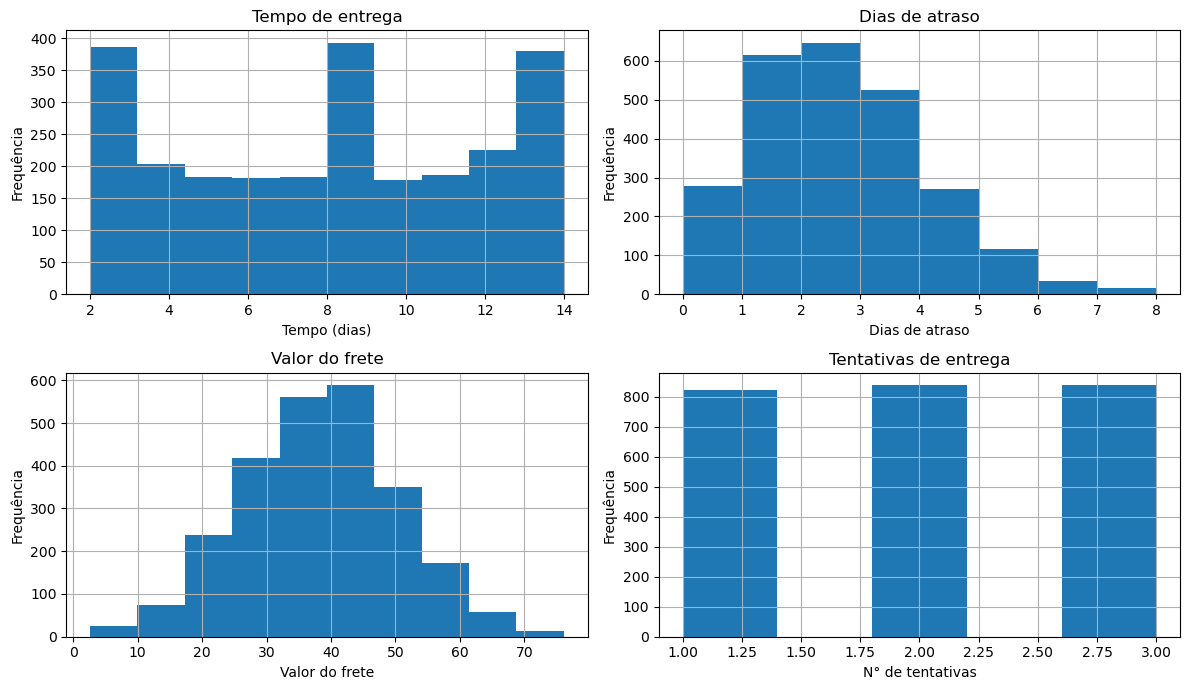

In [52]:
#Grades do plot em duas linhas e duas colunas
fig, axs = plt.subplots(2, 2, figsize=(12, 7))

# Gráfico 7, contendo o histograma do nº de dias para entrega do pedido
df['delivery_time_days'].hist(bins=10, ax = axs[0,0])
axs[0,0].set_xlabel('Tempo (dias)')
axs[0,0].set_ylabel('Frequência')
axs[0,0].set_title('Tempo de entrega')
axs[0,0].grid(True)

# Gráfico 8, contendo o histograma dos dias de atraso na entrega
df['delivery_delay_days'].hist(bins=8, ax = axs[0,1])
axs[0,1].set_xlabel('Dias de atraso')
axs[0,1].set_ylabel('Frequência')
axs[0,1].set_title('Dias de atraso')
axs[0,1].grid(True)

# Gráfico 9, contendo o histograma dos valores de frete
df['freight_value'].hist(bins=10, ax = axs[1,0])
axs[1,0].set_xlabel('Valor do frete')
axs[1,0].set_ylabel('Frequência')
axs[1,0].set_title('Valor do frete')
axs[1,0].grid(True)

# Gráfico 10, contendo o histograma do número de tentativas de entrega
df['delivery_attempts'].hist(bins=5, ax = axs[1,1])
axs[1,1].set_xlabel('N° de tentativas')
axs[1,1].set_ylabel('Frequência')
axs[1,1].set_title('Tentativas de entrega')
axs[1,1].grid(True)


plt.tight_layout()
plt.show()

### Dados de atendimento

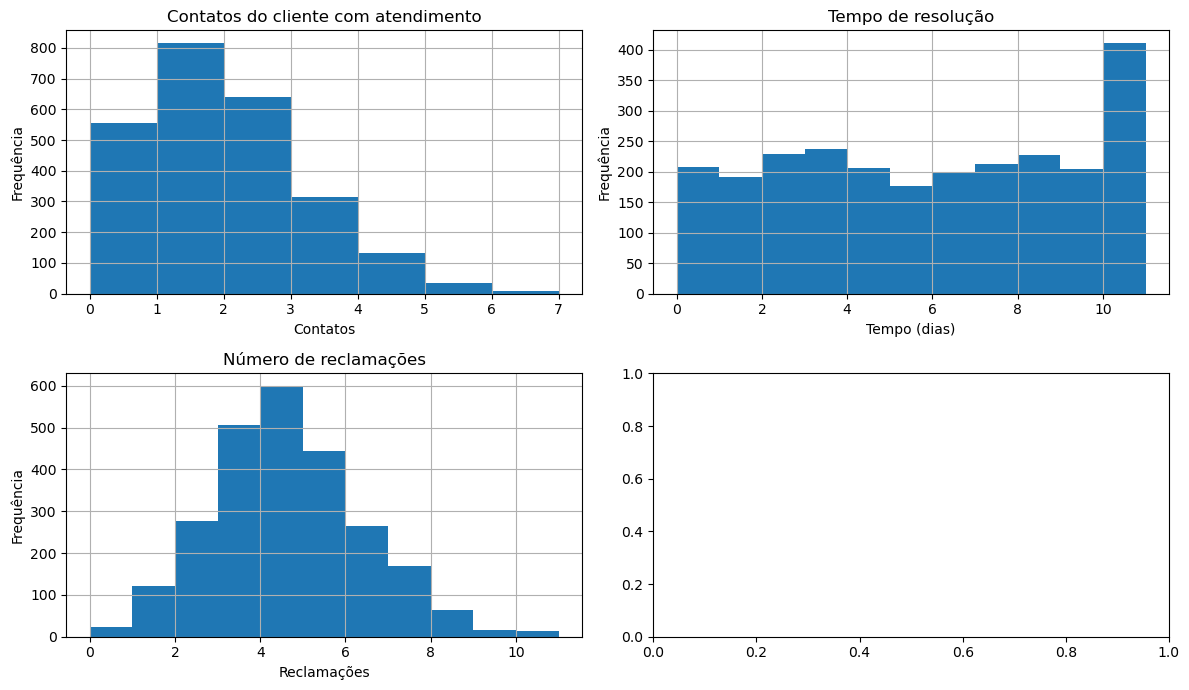

In [56]:
#Grades do plot em duas linhas e duas colunas
fig, axs = plt.subplots(2, 2, figsize=(12, 7))

# Gráfico 11, contendo o histograma do nº de contatos do cliente com o atendimento
df['customer_service_contacts'].hist(bins=7, ax = axs[0,0])
axs[0,0].set_xlabel('Contatos')
axs[0,0].set_ylabel('Frequência')
axs[0,0].set_title('Contatos do cliente com atendimento')
axs[0,0].grid(True)

# Gráfico 12, contendo o histograma dos dias que demoram para a resolução das demandas dos clientes
df['resolution_time_days'].hist(bins=11, ax = axs[0,1])
axs[0,1].set_xlabel('Tempo (dias)')
axs[0,1].set_ylabel('Frequência')
axs[0,1].set_title('Tempo de resolução')
axs[0,1].grid(True)

# Gráfico 13, contendo o histograma do número de reclamações
df['complaints_count'].hist(bins=11, ax = axs[1,0])
axs[1,0].set_xlabel('Reclamações')
axs[1,0].set_ylabel('Frequência')
axs[1,0].set_title('Número de reclamações')
axs[1,0].grid(True)

plt.tight_layout()
plt.show()

### Dados de satisfação

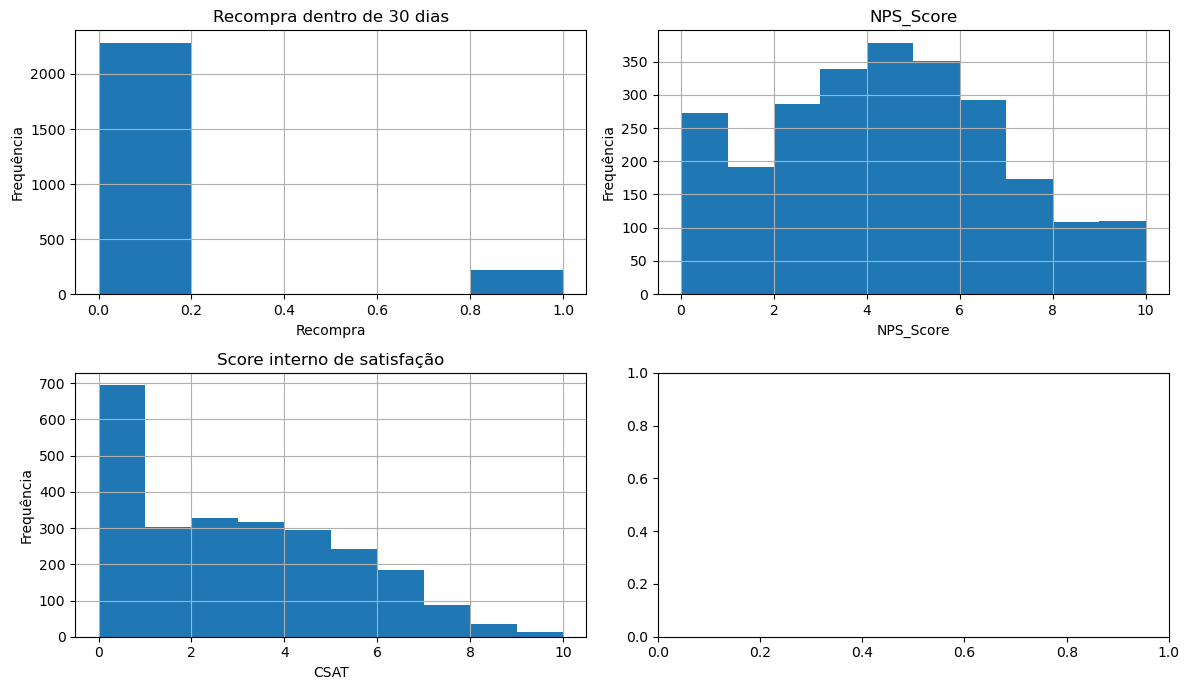

In [ ]:
#Grades do plot em duas linhas e duas colunas
fig, axs = plt.subplots(2, 2, figsize=(12, 7))

# Gráfico 14, contendo o histograma das recompras dentro de um mês
df['repeat_purchase_30d'].hist(bins=5, ax = axs[0,0])
axs[0,0].set_xlabel('Recompra')
axs[0,0].set_ylabel('Frequência')
axs[0,0].set_title('Recompra dentro de 30 dias')
axs[0,0].grid(True)

# Gráfico 15, contendo o histograma dos NPS_Score
df['nps_score'].hist(bins=10, ax = axs[0,1])
axs[0,1].set_xlabel('NPS_Score')
axs[0,1].set_ylabel('Frequência')
axs[0,1].set_title('NPS_Score')
axs[0,1].grid(True)

# Gráfico 16, contendo o histograma dos dados de CSAT
df['csat_internal_score'].hist(bins=10, ax = axs[1,0])
axs[1,0].set_xlabel('CSAT')
axs[1,0].set_ylabel('Frequência')
axs[1,0].set_title('Score interno de satisfação')
axs[1,0].grid(True)

plt.tight_layout()
plt.show()

A distribuçao dos dados de recompra apresenta uma concentração de menos de 300 pessoas entre os que recompraram. Podemos perceber no histograma do nps_score que o número de pessoas com notas 9 e 10 também foi abaixo de 300. É possível e até natural que exista uma relação entre notas altas e recompra.

O histograma de CSAT apresenta uma concentração maior de casos na primeira metade do gráfico, corroborando os dados de média e mediana apresentados anteriormente que apresentam um CSAT ainda pior que os dados de NPS.

## Outros

In [14]:
matriz_corr = df.drop(['customer_id','customer_region','order_id'],axis = 1).corr()
matriz_corr

,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
customer_age,1.000000,0.029889,0.011991,-0.004716,0.007017,-0.050824,0.022542,-0.002094,-0.015174,-0.026088,0.032706,0.005458,-0.009936,0.009017,0.008211,-0.015125
customer_tenure_months,0.029889,1.000000,0.011507,-0.003566,0.015332,0.000205,-0.017653,0.001198,-0.017503,-0.026009,-0.008960,-0.005167,-0.009711,0.024008,-0.009167,-0.000267
order_value,0.011991,0.011507,1.000000,0.003973,0.011670,0.042265,-0.021890,0.005971,-0.019107,-0.005792,0.032823,-0.014299,0.036990,0.023443,0.001893,0.000807
items_quantity,-0.004716,-0.003566,0.003973,1.000000,0.023730,-0.002980,0.020323,-0.014567,-0.011353,-0.020238,-0.014553,0.017519,0.011468,0.012073,0.024986,-0.005639
discount_value,0.007017,0.015332,0.011670,0.023730,1.000000,0.005823,-0.012101,-0.049742,0.020587,0.026542,0.016097,-0.017247,0.025104,0.014534,0.000792,0.040063
payment_installments,-0.050824,0.000205,0.042265,-0.002980,0.005823,1.000000,-0.007901,-0.026633,-0.000634,0.023752,0.025483,0.015277,0.023718,-0.010714,-0.001881,0.001777
delivery_time_days,0.022542,-0.017653,-0.021890,0.020323,-0.012101,-0.007901,1.000000,-0.006589,-0.017541,-0.019562,0.007706,0.021217,0.000925,0.006094,-0.008998,-0.024835
delivery_delay_days,-0.002094,0.001198,0.005971,-0.014567,-0.049742,-0.026633,-0.006589,1.000000,0.003779,0.005189,-0.024167,-0.015297,-0.597260,-0.304014,0.190225,-0.459051
freight_value,-0.015174,-0.017503,-0.019107,-0.011353,0.020587,-0.000634,-0.017541,0.003779,1.000000,0.004010,0.024790,-0.008003,-0.041087,-0.025603,0.022673,-0.014962
delivery_attempts,-0.026088,-0.026009,-0.005792,-0.020238,0.026542,0.023752,-0.019562,0.005189,0.004010,1.000000,-0.012063,0.014928,0.027680,0.013527,-0.006905,-0.004514


In [15]:
def calcular_nps(notas):
    defensores = np.sum(notas >= 9)
    detratores = np.sum(notas <= 6)
    return 100*(defensores - detratores)/len(notas)

In [16]:
df.groupby('customer_region')['nps_score'].apply(calcular_nps).sort_values(ascending=False).reset_index().rename(columns={'nps_score':'NPS'})

,customer_region,NPS
0,Sul,-68.330134
1,Centro-Oeste,-69.017094
2,Nordeste,-69.690722
3,Sudeste,-70.192308
4,Norte,-70.948617


<Axes: xlabel='customer_region'>

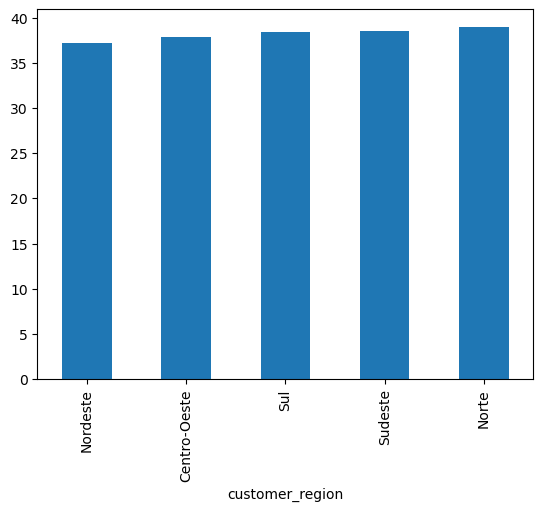

In [17]:
df.groupby('customer_region')['freight_value'].mean().sort_values(ascending=True).plot(kind='bar', x='customer_region', y='freight_value')

In [ ]:
def calcula_faixa_NPS(score):
  if score <= 2:
    return '[0-2]'
  if score <= 4 and score>2:
    return '[2-4]'
  if score <=6 and score > 4:
    return '[4-6]'
  if score <=9 and score >6:
    return '[6-9]'
  return '[9-10]'


df['faixa_NPS'] = df['nps_score'].map(calcula_faixa_NPS)
df['porc_desconto'] = 100*df['discount_value']/df['order_value']
df['porc_frete'] = 100*df['freight_value']/df['order_value']

def calcula_atraso(dias):
  if(dias > 0):
    return 1
  return 0

df['atraso'] = df['delivery_delay_days'].map(calcula_atraso)

def calcula_faixa_etaria(anos):
  if(anos >= 60):
    return 'idoso'
  if(anos >= 30 and anos < 60):
    return 'adulto'
  return 'jovem'

df['faixa_etaria'] = df['customer_age'].map(calcula_faixa_etaria)

df

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,faixa_NPS,porc_desconto,porc_frete,atraso,faixa_etaria
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,4,6.9,0,3,6.5,[6-9],28.161454,39.740929,1,idoso
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,10,2.4,0,3,0.0,[2-4],2.072121,6.150997,1,jovem
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,5,4.8,0,7,1.5,[4-6],8.444760,8.083856,1,adulto
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,...,11,5.9,0,4,0.3,[4-6],6.479367,11.661537,1,adulto
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,...,0,6.1,0,3,7.9,[6-9],11.605943,15.537817,1,adulto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,51,Sul,96,52496,615.81,6,11.41,2,14,...,2,3.7,0,3,4.3,[2-4],1.852844,4.702749,1,adulto
2496,2497,37,Sul,89,52497,73.03,1,36.44,3,12,...,7,3.7,0,4,2.5,[2-4],49.897302,37.546214,1,adulto
2497,2498,19,Sudeste,98,52498,522.78,1,4.84,9,2,...,1,7.4,0,3,6.2,[6-9],0.925820,7.448640,1,jovem
2498,2499,41,Sul,51,52499,55.87,2,2.11,2,14,...,0,2.3,0,5,1.7,[2-4],3.776624,52.085198,1,adulto


In [19]:
df.groupby('faixa_NPS')['customer_age'].mean().sort_values(ascending=True)

faixa_NPS
[2-4]     42.791139
[4-6]     43.164609
[9-10]    43.542857
[6-9]     43.661765
[0-2]     44.193878
Name: customer_age, dtype: float64

In [20]:
df.groupby('faixa_NPS')['customer_tenure_months'].mean().sort_values(ascending=True)

faixa_NPS
[6-9]     60.101103
[4-6]     61.146776
[2-4]     61.594937
[0-2]     62.187755
[9-10]    63.190476
Name: customer_tenure_months, dtype: float64

In [21]:
df.groupby('faixa_NPS')['order_value'].mean().sort_values(ascending=True)

faixa_NPS
[0-2]     413.502898
[4-6]     432.618642
[2-4]     436.798497
[6-9]     447.690551
[9-10]    457.653619
Name: order_value, dtype: float64

In [22]:
df.groupby('faixa_NPS')['discount_value'].mean().sort_values(ascending=True)

faixa_NPS
[0-2]     28.871816
[2-4]     29.353386
[6-9]     29.539614
[4-6]     30.382593
[9-10]    32.829143
Name: discount_value, dtype: float64

In [23]:
df.groupby('faixa_NPS')['porc_desconto'].mean().sort_values(ascending=True)

faixa_NPS
[6-9]     11.865063
[4-6]     11.919028
[9-10]    12.423468
[0-2]     12.982428
[2-4]     13.433059
Name: porc_desconto, dtype: float64

In [24]:
df.groupby('faixa_NPS')['payment_installments'].mean().sort_values(ascending=True)

faixa_NPS
[0-2]     5.826531
[9-10]    5.895238
[4-6]     6.016461
[2-4]     6.022152
[6-9]     6.147059
Name: payment_installments, dtype: float64

In [25]:
df.groupby('faixa_NPS')['delivery_time_days'].mean().sort_values(ascending=True)

faixa_NPS
[9-10]    7.933333
[2-4]     7.974684
[4-6]     7.975309
[0-2]     8.053061
[6-9]     8.128676
Name: delivery_time_days, dtype: float64

In [26]:
df.groupby('faixa_NPS')['freight_value'].mean().sort_values(ascending=True)

faixa_NPS
[9-10]    37.350571
[6-9]     37.757923
[4-6]     37.776914
[2-4]     38.750506
[0-2]     38.879041
Name: freight_value, dtype: float64

In [27]:
df.groupby('faixa_NPS')['porc_frete'].mean().sort_values(ascending=True)

faixa_NPS
[9-10]    12.783291
[6-9]     14.063272
[4-6]     14.880803
[2-4]     16.687252
[0-2]     17.285475
Name: porc_frete, dtype: float64

A porcentagem do frete sobre o valor total da compra sugere que clientes que pagam fretes proporcionalmente mais baixos em relação ao valor total da compra tendem a dar notas maiores. Essa informação pode sugerir uma possível utilização de cupom de frete grátis, como uma forma de remediar as dores do cliente em relação ao atraso na entrega ou número de dias para resolução do problema.

In [28]:
df.groupby('customer_region')['freight_value'].mean().sort_values(ascending=True)

customer_region
Nordeste        37.254887
Centro-Oeste    37.872329
Sul             38.399175
Sudeste         38.504442
Norte           38.975079
Name: freight_value, dtype: float64

In [29]:
df.groupby('faixa_NPS')['delivery_attempts'].mean().sort_values(ascending=True)

faixa_NPS
[2-4]     1.982595
[0-2]     1.997959
[4-6]     1.998628
[6-9]     2.020221
[9-10]    2.152381
Name: delivery_attempts, dtype: float64

In [30]:
df.groupby('faixa_NPS')['customer_service_contacts'].mean().sort_values(ascending=True)

faixa_NPS
[9-10]    0.695238
[6-9]     1.084559
[4-6]     1.371742
[2-4]     1.716772
[0-2]     2.144898
Name: customer_service_contacts, dtype: float64

Clientes que entram muito em contato tendem a dar notas menores, evidenciando uma necessidade maior de atendimento resolutivo.

In [31]:
df.groupby('faixa_NPS')['resolution_time_days'].mean().sort_values(ascending=True)

faixa_NPS
[9-10]    3.733333
[6-9]     4.775735
[4-6]     5.427984
[2-4]     5.727848
[0-2]     6.422449
Name: resolution_time_days, dtype: float64

<Axes: xlabel='faixa_NPS'>

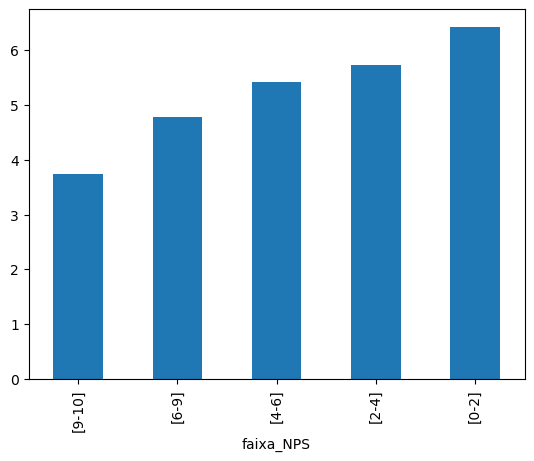

In [32]:
df.groupby('faixa_NPS')['resolution_time_days'].mean().sort_values(ascending=True).plot(kind='bar')

O tempo de resolução também parece estar intimamente ligado aos resultados de NPS

In [33]:
df.groupby('faixa_NPS')['complaints_count'].mean().sort_values(ascending=True)

faixa_NPS
[9-10]    2.295238
[6-9]     2.900735
[4-6]     4.189300
[2-4]     4.659810
[0-2]     5.220408
Name: complaints_count, dtype: float64

In [34]:
df.groupby('faixa_NPS')['delivery_delay_days'].mean().sort_values(ascending=True)

faixa_NPS
[9-10]    0.704762
[6-9]     1.292279
[4-6]     1.847737
[2-4]     2.530063
[0-2]     3.561224
Name: delivery_delay_days, dtype: float64

In [35]:
df.groupby('faixa_NPS')['csat_internal_score'].mean().sort_values(ascending=True)

faixa_NPS
[0-2]     1.137755
[2-4]     2.222310
[4-6]     3.251303
[6-9]     4.391728
[9-10]    6.025714
Name: csat_internal_score, dtype: float64

In [36]:
df_filtered = df[df['faixa_NPS'] == '[0-2]']
df_filtered['customer_region'].value_counts()



customer_region
Centro-Oeste    111
Sudeste         101
Norte            99
Sul              94
Nordeste         85
Name: count, dtype: int64

In [37]:
df_filtered = df[df['faixa_NPS'] == '[9-10]']
df_filtered['customer_region'].value_counts()

customer_region
Centro-Oeste    24
Sul             23
Sudeste         21
Nordeste        20
Norte           17
Name: count, dtype: int64

In [38]:
df['customer_region'].value_counts()

customer_region
Sul             521
Sudeste         520
Norte           506
Nordeste        485
Centro-Oeste    468
Name: count, dtype: int64

In [39]:
df.groupby('customer_region')['delivery_time_days'].mean().sort_values(ascending=True)

customer_region
Norte           7.758893
Centro-Oeste    7.912393
Sul             8.067179
Nordeste        8.160825
Sudeste         8.201923
Name: delivery_time_days, dtype: float64

In [40]:
df.groupby('atraso')['nps_score'].mean().sort_values(ascending=True)

atraso
1    4.069816
0    6.856679
Name: nps_score, dtype: float64

In [41]:
df['atraso'].value_counts()

atraso
1    2223
0     277
Name: count, dtype: int64

O dado de atraso nos mostra que apenas 11% das entregas foram no prazo estipulado. Já a relação entre o nps_score e o atraso na entrega nos mostra que quanto maior o atraso, menor é o NPS resultante. Além disso, verificamos que não parece haver uma correlação elevada entre o número de dias para a entrega e o nps_score. Analisando esses fatos em perspectiva, percebemos que uma possível forma de reduzir o impacto do atraso sobre o NPS seria informar ao cliente um número de dias um pouco maior para a entrega do produto.

In [42]:
df['faixa_etaria'].value_counts()

faixa_etaria
adulto    1476
jovem      561
idoso      463
Name: count, dtype: int64

In [43]:
df.groupby('faixa_etaria')['nps_score'].mean().sort_values(ascending=True)

faixa_etaria
adulto    4.285637
idoso     4.474730
jovem     4.543850
Name: nps_score, dtype: float64

<Axes: xlabel='customer_service_contacts'>

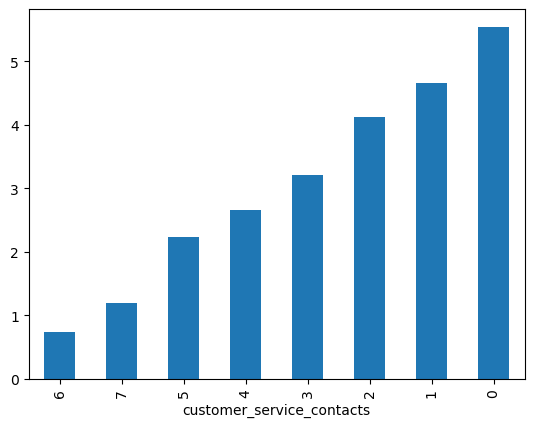

In [44]:
df.groupby('customer_service_contacts')['nps_score'].mean().sort_values(ascending=True).plot(kind='bar', x='customer_service_contacts', y='NPS')